<a href="https://colab.research.google.com/github/Sinem-B62/Natural-Language-Process--Project/blob/main/NLP_Project_Katastrophen_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP-Projekt: Klassifizierung von Katastrophen-Tweets**

Das Ziel dieses Notebooks ist es, ein NLP-Modell zu trainieren, das Tweets als "Katastrophe" (1) oder "Nicht-Katastrophe" (0) erkennt.

Dafür wird ein Logistisches Regressionsmodell auf den bereinigten und mittels TF-IDF vektorisierten Tweet-Texten trainiert. Die Leistung des Modells wird anschließend bewertet und optimiert.

## **Import aller Bibliotheken**

In [ ]:
import numpy as np
import pandas as pd
import random  # zum Mischen der Daten
import nltk
import re  # zur Verarbeitung regulärer Ausdrücke

from nltk.stem import WordNetLemmatizer  # zum Lemmatisieren
from nltk.corpus import stopwords  # zur Entfernung von Stoppwörtern
from nltk.tokenize import word_tokenize  # zum Tokenisieren
nltk.download('punkt_tab')  # lädt die Tokenizer-Tabelle 'punkt' herunter

# Herunterladen der Natural Language Toolkit
nltk.download('stopwords')  # Liste häufiger Stoppwörter im englischen
nltk.download('punkt')  # Vorab trainierte Tokenizer-Modelle
nltk.download('wordnet')  # WordNet-Lemmatiser-Datensatz

# Bibliotheken zur Extraction von Textmerkmalen und zum Modelltraining
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Bibliotheken zur Modellevaluierung
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Einlesen und Vorverarbeiten der Daten**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Projekt_NLP_train.csv to Projekt_NLP_train (8).csv


In [ ]:
df_train = pd.read_csv('Projekt_NLP_train.csv', sep=',')

In [ ]:
df_train

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...
7608,Two giant cranes holding a bridge collapse int...,1
7609,@aria_ahrary @TheTawniest The out of control w...,1
7610,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,Police investigating after an e-bike collided ...,1


### Textvorverarbeitung

In [ ]:
def preprocess_single_text(text):

    # Stoppwörter und Lemmatizer initialisieren
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    # 1. Kleinbuchstaben & 2. Zeichen entfernen
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)

    # 3. Tokenisieren (in Wörter zerlegen)
    tokens = word_tokenize(text)

    # 4. Stoppwörter entfernen & 5. Lemmatisieren
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # 6. Wieder zu einem String zusammenfügen
    return " ".join(processed_tokens)

# --- 2. Funktion auf die Spalte anwenden ---
df_train['processed_text'] = df_train['text'].apply(preprocess_single_text)

In [ ]:
df_train.drop('text', axis=1, inplace=True)

In [ ]:
df_train

,target,processed_text
0,1,deed reason earthquake may allah forgive u
1,1,forest fire near la ronge sask canada
2,1,resident asked shelter place notified officer ...
3,1,13000 people receive wildfire evacuation order...
4,1,got sent photo ruby alaska smoke wildfire pour...
...,...,...
7608,1,two giant crane holding bridge collapse nearby...
7609,1,aria_ahrary thetawniest control wild fire cali...
7610,1,m194 0104 utc5km volcano hawaii httptcozdtoyd8ebj
7611,1,police investigating ebike collided car little...


### Textvektorisierung

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Den Vectorizer initialisieren
# Beschränkung der Features auf 5000, um die Matrixgröße zu kontrollieren.
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Vectorizer auf die Textdaten anwenden (fitten und transformieren)
X = vectorizer.fit_transform(df_train['processed_text'])

# 3. Das "Target" (die Zielvariable) definieren
y = df_train['target']

# 4. Die Form der Ergebnisse anzeigen
print("Form der X-Matrix (Texte, Features):", X.shape)
print("Form der y-Matrix (Labels):", y.shape)

Form der X-Matrix (Texte, Features): (7613, 5000)
Form der y-Matrix (Labels): (7613,)


## **Modellauswahl**

### 1. Daten aufteilen (Train-Test-Split)

In [ ]:
from sklearn.model_selection import train_test_split

# Daten aufteilen (z.B. 80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (6090, 5000)
Testdaten: (1523, 5000)


### 2. Modell trainieren (Logistische Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Modell initialisieren
model = LogisticRegression()

# 2. Modell mit den Trainingsdaten trainieren
model.fit(X_train, y_train)

print("Modell erfolgreich trainiert!")

Modell erfolgreich trainiert!


### 3. Modell bewerten

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersagen auf den Testdaten machen
y_pred = model.predict(X_test)

# 2. Genauigkeit (Accuracy) berechnen
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit des Modells: {accuracy * 100:.2f}%")
print("-" * 30)

# 3. Detaillierten Report anzeigen (Precision, Recall, F1-Score)
print("Klassifikations-Report:")
print(classification_report(y_test, y_pred))

Genauigkeit des Modells: 79.84%
------------------------------
Klassifikations-Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       874
           1       0.82      0.67      0.74       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.79      1523



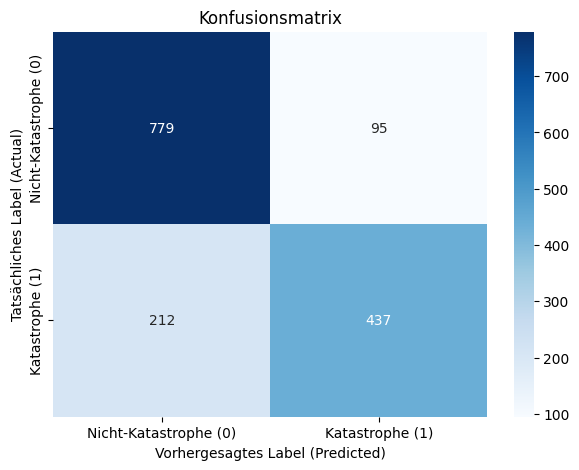

In [ ]:
# 1. Konfusionsmatrix berechnen
cm = confusion_matrix(y_test, y_pred)

# 2. Matrix visualisieren
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'],
            yticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'])

plt.title('Konfusionsmatrix')
plt.ylabel('Tatsächliches Label (Actual)')
plt.xlabel('Vorhergesagtes Label (Predicted)')
plt.show()

## Optinal: RandomForest Modell

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Modell initialisieren
# n_estimators=100 ist ein guter Standard (das Modell baut 100 Bäume)
# random_state=42 sorgt dafür, dass du das Ergebnis reproduzieren kannst
# n_jobs=-1 nutzt alle CPU-Kerne, um das Training zu beschleunigen
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Modell trainieren
print("Starte Training des Random Forest...")
model_rf.fit(X_train, y_train)
print("Random Forest erfolgreich trainiert!")

Starte Training des Random Forest...
Random Forest erfolgreich trainiert!


Genauigkeit des Random Forest: 77.08%
------------------------------
Klassifikations-Report (Random Forest):
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       874
           1       0.76      0.68      0.72       649

    accuracy                           0.77      1523
   macro avg       0.77      0.76      0.76      1523
weighted avg       0.77      0.77      0.77      1523

------------------------------


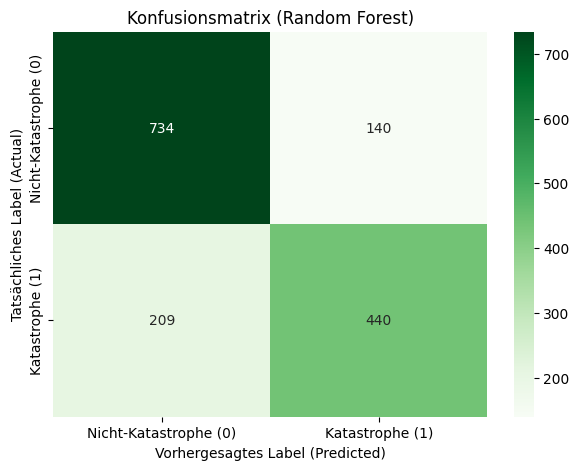

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vorhersagen auf den Testdaten machen
y_pred_rf = model_rf.predict(X_test)

# 2. Genauigkeit (Accuracy) berechnen
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Genauigkeit des Random Forest: {accuracy_rf * 100:.2f}%")
print("-" * 30)

# 3. Detaillierten Report anzeigen
print("Klassifikations-Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("-" * 30)

# 4. Konfusionsmatrix visualisieren
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'],
            yticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'])

plt.title('Konfusionsmatrix (Random Forest)')
plt.ylabel('Tatsächliches Label (Actual)')
plt.xlabel('Vorhergesagtes Label (Predicted)')
plt.show()

## Optinal: Neuronales Netz (MLP) trainieren

In [ ]:
from sklearn.neural_network import MLPClassifier

# 1. Modell initialisieren

# hidden_layer_sizes=(100,):
#   Definiert die Architektur des Netzes. In diesem Fall wird
#   EIN hidden layer (eine versteckte Schicht) mit 100 Neuronen verwendet.
#   Dies bestimmt die Kapazität bzw. "Größe" des Modells.

# max_iter=500:
#   Legt die maximale Anzahl an Trainings-Iterationen (Epochen) fest.

# early_stopping=True:
#   Aktiviert einen Mechanismus zur frühzeitigen Beendigung.
#   Hierbei stoppt das Modell das Training automatisch, sobald es feststellt, dass sich die Leistung nicht mehr verbessert.
#   Dies spart Rechenzeit und hilft, Overfitting zu verhindern.

model_nn = MLPClassifier(hidden_layer_sizes=(100,),
                         max_iter=500,
                         random_state=42,
                         early_stopping=True)

# 2. Modell trainieren
print("Starte Training des Neuronalen Netzes (MLP)...")

model_nn.fit(X_train, y_train)
print("Neuronales Netz erfolgreich trainiert!")

Starte Training des Neuronalen Netzes (MLP)...
Neuronales Netz erfolgreich trainiert!


Genauigkeit des Neuronalen Netzes: 79.71%
------------------------------
Klassifikations-Report (Neuronales Netz):
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       874
           1       0.83      0.66      0.73       649

    accuracy                           0.80      1523
   macro avg       0.81      0.78      0.79      1523
weighted avg       0.80      0.80      0.79      1523

------------------------------


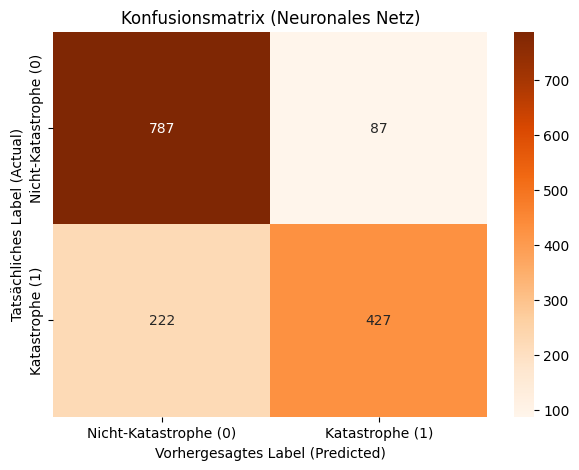

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vorhersagen auf den Testdaten machen
y_pred_nn = model_nn.predict(X_test)

# 2. Genauigkeit (Accuracy) berechnen
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Genauigkeit des Neuronalen Netzes: {accuracy_nn * 100:.2f}%")
print("-" * 30)

# 3. Detaillierten Report anzeigen
print("Klassifikations-Report (Neuronales Netz):")
print(classification_report(y_test, y_pred_nn))
print("-" * 30)

# 4. Konfusionsmatrix visualisieren
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'],
            yticklabels=['Nicht-Katastrophe (0)', 'Katastrophe (1)'])

plt.title('Konfusionsmatrix (Neuronales Netz)')
plt.ylabel('Tatsächliches Label (Actual)')
plt.xlabel('Vorhergesagtes Label (Predicted)')
plt.show()

## **Hyperparameter-Optimierung**

### 1. Kreuzvalidierung

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# 1. Initialisiere das Standardmodell (mit den Standard-Einstellungen)
model_default = LogisticRegression()

# 2. Führt die 5-fache Kreuzvalidierung durch
#    cv=5 teilt die Daten in 5 "Folds"
scores = cross_val_score(model_default, X, y, cv=5, scoring='accuracy')

# 3. Ergebnisse anzeigen
print("--- Kreuzvalidierung (Standardmodell) ---")
print(f"Genauigkeit für jeden Fold: {scores}")
print(f"Durchschnittliche Genauigkeit: {scores.mean() * 100:.2f}%")
print(f"Standardabweichung: {scores.std() * 100:.2f}%")

--- Kreuzvalidierung (Standardmodell) ---
Genauigkeit für jeden Fold: [0.72882469 0.66119501 0.67564018 0.67936925 0.76412615]
Durchschnittliche Genauigkeit: 70.18%
Standardabweichung: 3.86%


### 2. Hyperparameter-Optimierung (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Definiere das "Gitter" der Parameter, die wir testen wollen
#    - 'C': Regularisierungsstärke. Kleine Werte = stärkere Regularisierung.
#    - 'solver': Der Algorithmus, der zum Optimieren verwendet wird.
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs']
}

# 2. Initialisiere das Modell
model_lr = LogisticRegression()

# 3. Initialisiere die GridSearchCV
#    - estimator: Das Modell, das wir tunen wollen
#    - param_grid: Das Gitter, das durchsucht wird
#    - cv=5: Verwendet 5-fache Kreuzvalidierung für jede Parameter-Kombination
#    - n_jobs=-1: Verwendet alle verfügbaren CPU-Kerne, um die Suche zu beschleunigen
grid_search = GridSearchCV(estimator=model_lr,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# 4. Starte die Suche (das kann ein paar Momente dauern)
#    Wir verwenden hier die Trainingsdaten (X_train, y_train)
grid_search.fit(X_train, y_train)

# 5. Beste Ergebnisse anzeigen
print("\n--- Hyperparameter-Optimierung (GridSearchCV) ---")
print(f"Beste Parameter gefunden: {grid_search.best_params_}")
print(f"Beste Genauigkeit (im Training): {grid_search.best_score_ * 100:.2f}%")

# 6. Bewerte das *optimierte* Modell auf den Testdaten
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"\nGenauigkeit des optimierten Modells auf Testdaten: {accuracy_best * 100:.2f}%")


--- Hyperparameter-Optimierung (GridSearchCV) ---
Beste Parameter gefunden: {'C': 1.0, 'solver': 'lbfgs'}
Beste Genauigkeit (im Training): 79.87%

Genauigkeit des optimierten Modells auf Testdaten: 79.84%


# **Projektzusammenfassung & Fazit:**

---

In diesem Projekt wurde ein NLP-Modell (Natural Language Processing) entwickelt, um Tweets automatisch in zwei Kategorien zu klassifizieren: "reale Katastrophe" (1) oder "keine Katastrophe" (0).


**Vorgehensweise**

1. Datenaufbereitung: Die Textdaten wurden zunächst eingelesen und einer umfassenden Bereinigung unterzogen. Dazu gehörten die Umwandlung in Kleinbuchstaben, die Entfernung von Satzzeichen und Sonderzeichen sowie die Eliminierung gängiger englischer Stoppwörter.

2. Lemmatisierung: Um die Wörter auf ihre Grundform zurückzuführen (z.B. "running" -> "run"), wurde eine Lemmatisierung durchgeführt.

3. Vektorisierung: Die bereinigten Tweets wurden mithilfe des TF-IDF-Verfahrens (TfidfVectorizer) in eine numerische Matrix umgewandelt. Die Anzahl der Features wurde dabei auf die 5.000 wichtigsten Wörter beschränkt.

4. Modelltraining: Ein Logistisches Regressionsmodell wurde auf den aufbereiteten Trainingsdaten trainiert.

**Ergebnisse und Erkenntnisse**

Das trainierte Modell erreichte auf dem separaten Test-Set eine Gesamtgenauigkeit (Accuracy) von 79.84%.

Die detaillierte Analyse der Konfusionsmatrix und des Klassifikations-Reports offenbarte jedoch wichtige Details:

- Stärke: Das Modell kann Tweets, die keine Katastrophe sind (Klasse 0), sehr zuverlässig erkennen (Recall von 89%).

- Schwäche: Die größte Herausforderung war das korrekte Identifizieren von echten Katastrophen (Klasse 1). Hier lag der Recall bei nur 67%. Das bedeutet, dass das Modell fast ein Drittel (212 Fälle) der echten Katastrophen-Tweets übersah und fälschlicherweise als "keine Katastrophe" einstufte (Falsch Negative).


**Validierung und Optimierung**

**Kreuzvalidierung**: Eine 5-fache Kreuzvalidierung (cross_val_score) auf dem gesamten Datensatz lieferte eine robustere, durchschnittliche Genauigkeit von 70.18%. Dies zeigt, dass die anfängliche 80/20-Aufteilung der Daten leicht optimistisch war.

**Hyperparameter-Tuning**: Eine systematische Suche (GridSearchCV) nach den besten Modell-Parametern (C und solver) bestätigte, dass die Standardeinstellungen bereits die optimale Leistung für dieses Setup erbrachten.

---

### **Ausblick**

Obwohl eine Genauigkeit von ~80% ein solider Start ist, stellt der niedrige Recall für Katastrophen-Tweets ein klares Verbesserungspotenzial dar. Zukünftige Iterationen könnten alternative Modelle (z.B. Naive Bayes, Random Forest) oder fortgeschrittenere Techniken wie Transfer Learning (z.B. mit BERT-Modellen) evaluieren, um die Anzahl der übersehenen Katastrophen zu reduzieren.

## **Modellvergleich und Bewertung**

### **Modellvergleich und Bewertung**

Um die Leistung des initialen Logistischen Regressionsmodells einzuordnen, wurden zwei weitere Modelle auf denselben Daten trainiert und bewertet: ein Random Forest und ein Neuronales Netz (MLPClassifier).


Der Vergleich zeigt deutliche Kompromisse (Trade-offs) zwischen den Modellen:

1. **Gesamtgenauigkeit (Accuracy):**

- Logistische Regression: 79.84%

- Neuronales Netz: 79.71%

- Random Forest: 77.08%


Auf den ersten Blick liefern die Logistische Regression und das Neuronale Netz die besten Gesamt-Ergebnisse.


2. **Analyse der "Katastrophen"-Klasse (Recall für Klasse 1):** Das wichtigste Ziel ist, möglichst wenige echte Katastrophen zu übersehen (also die Anzahl der "Falsch Negativen" zu minimieren).

- Random Forest: Übersah 209 Katastrophen (Recall: 0.68)

- Logistische Regression: Übersah 212 Katastrophen (Recall: 0.67)

- Neuronales Netz: Übersah 222 Katastrophen (Recall: 0.66)

Hier zeigt sich: Obwohl der Random Forest die niedrigste Gesamtgenauigkeit hat, ist er das sensibelste Modell und findet die meisten echten Katastrophen.


3. **Analyse der "Keine Katastrophe"-Klasse (Recall für Klasse 0):** Hier geht es darum, wie gut die Modelle "Fehlalarme" (Falsch Positive) vermeiden.

- Neuronales Netz: Lösste nur 87 Mal Fehlalarm aus (Recall: 0.90)

- Logistische Regression: Lösste 95 Mal Fehlalarm aus (Recall: 0.89)

- Random Forest: Lösste 140 Mal Fehlalarm aus (Recall: 0.84)

Das Neuronale Netz ist am "vorsichtigsten" und klassifiziert Nicht-Katastrophen am zuverlässigsten.

---
### **Fazit des Vergleichs**

Es gibt keinen perfekten Gewinner. Die Modellauswahl hängt vom Ziel ab:

Das Neuronale Netz und die Logistische Regression sind die besten, wenn eine hohe Gesamtgenauigkeit und die Vermeidung von Fehlalarmen (Falsch Positive) im Vordergrund stehen.

Der Random Forest ist die beste Wahl, wenn das primäre Ziel darin besteht, so viele echte Katastrophen wie möglich zu finden (Recall für Klasse 1), auch wenn dies auf Kosten einer niedrigeren Gesamtgenauigkeit und mehr Fehlalarmen geht.